# Lab 3: Hyperparameter Tuning

**Date:** February 2026  
**GCP Project:** carty-470812  
**Dataset:** Census Income (adult_income)  
**Baseline Accuracy:** 87.10% (Lab 2 custom training)  

---

## Overview

This lab explores hyperparameter tuning in three parts:

1. **Part 1: Manual Tuning** — Run experiments locally, track results, experience the pain
2. **Part 2: Vertex AI Hyperparameter Tuning** — Let Bayesian optimization do the work
3. **Part 3: Visualization & Analysis** — Which hyperparameters mattered? Was tuning worth it?

### Key Questions We'll Answer
- Did accuracy improve significantly beyond our 87.10% baseline?
- Which hyperparameters have the biggest impact?
- Where do we hit diminishing returns?
- What's the optimal balance of cost vs. performance?

---

## Part 1: Manual Hyperparameter Tuning

### Why Start Manually?

Before using automated tuning, it's valuable to:
- Build intuition for how each hyperparameter affects performance
- Understand the search space before automating it
- Appreciate *why* automated tuning exists (it's tedious manually!)
- Establish a fair comparison for Vertex AI tuning later

In [15]:
!pip install matplotlib adjustText


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
# Load the census data

DATA_PATH = "../lab2/census_income.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head(3)

Loaded 32,561 rows, 15 columns


,age,workclass,functional_weight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,Private,297847,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,3411,0,34,United-States,<=50K
1,77,Private,344425,9th,5,Married-civ-spouse,Priv-house-serv,Wife,Black,Female,0,0,10,United-States,<=50K
2,38,Private,131461,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,24,Haiti,<=50K


In [ ]:
# Preprocessing — same as Lab 2 train.py
def preprocess(df, target_column='income_bracket'):
    """Reproduce the exact preprocessing from our Lab 2 training script."""
    X = df.drop(columns=[target_column])
    y = df[target_column].str.strip()
    y = (y == '>50K').astype(int)
    X = pd.get_dummies(X, drop_first=True)
    return X, y

X, y = preprocess(df)
print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Positive class ratio: {y.mean():.2%}")

Features: 100
Target distribution:
income_bracket
0    24720
1     7841
Name: count, dtype: int64
Positive class ratio: 24.08%


In [ ]:
# Train/test split — use the SAME random_state as Lab 2 for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows")
print(f"Test:  {len(X_test):,} rows")

Train: 26,048 rows
Test:  6,513 rows


### Establish Baseline

First, let's reproduce our Lab 2 result locally to confirm we get the same number.
Lab 2 used: `n_estimators=100, max_depth=5, learning_rate=0.1, min_samples_split=2`

In [ ]:
def train_and_evaluate(hyperparams, X_train, y_train, X_test, y_test):
    """Train a model with given hyperparameters and return all metrics.
    
    This function is the workhorse of Part 1 — we'll call it many times
    with different hyperparameter combinations.
    """
    start_time = time.time()
    
    model = GradientBoostingClassifier(
        **hyperparams,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'train_time_sec': round(train_time, 1)
    }
    
    return model, metrics

In [ ]:
# Baseline: Lab 2 hyperparameters
baseline_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.1,
    'min_samples_split': 2
}

baseline_model, baseline_metrics = train_and_evaluate(
    baseline_params, X_train, y_train, X_test, y_test
)

print("=" * 50)
print("BASELINE (Lab 2 hyperparameters)")
print("=" * 50)
for param, val in baseline_params.items():
    print(f"  {param}: {val}")
print("-" * 50)
for metric, val in baseline_metrics.items():
    if metric == 'train_time_sec':
        print(f"  {metric}: {val}s")
    else:
        print(f"  {metric}: {val:.4f} ({val*100:.2f}%)")
print("=" * 50)

BASELINE (Lab 2 hyperparameters)
  n_estimators: 100
  max_depth: 5
  learning_rate: 0.1
  min_samples_split: 2
--------------------------------------------------
  accuracy: 0.8710 (87.10%)
  roc_auc: 0.9304 (93.04%)
  precision: 0.7857 (78.57%)
  recall: 0.6384 (63.84%)
  f1: 0.7044 (70.44%)
  train_time_sec: 3.5s


### Manual Tuning Experiments

Now let's systematically vary hyperparameters. The strategy:

**GradientBoostingClassifier key hyperparameters:**

| Parameter | What it controls | Too low | Too high |
|-----------|-----------------|---------|----------|
| `n_estimators` | Number of boosting rounds | Underfitting | Overfitting + slow |
| `max_depth` | Tree complexity | Underfitting | Overfitting |
| `learning_rate` | Step size per round | Needs more estimators | Overshoot, unstable |
| `min_samples_split` | Min samples to split a node | Overfitting | Underfitting |

We'll test 10 combinations to build intuition about each parameter's effect.

In [ ]:
# Define experiments
# Strategy: start from baseline, vary one or two params at a time to understand impact
experiments = {
    'baseline': {
        'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    
    # --- Vary n_estimators ---
    'fewer_trees': {
        'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    'more_trees': {
        'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    'many_trees': {
        'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    
    # --- Vary max_depth ---
    'shallow_trees': {
        'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    'deeper_trees': {
        'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'min_samples_split': 2
    },
    
    # --- Vary learning_rate ---
    'slow_learner': {
        'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'min_samples_split': 2
    },
    'fast_learner': {
        'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.3, 'min_samples_split': 2
    },
    
    # --- Vary min_samples_split ---
    'more_regularized': {
        'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 10
    },
    
    # --- Combined: "best guess" based on intuition ---
    'best_guess': {
        'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 5
    },
}

print(f"Defined {len(experiments)} experiments")
for name, params in experiments.items():
    print(f"  {name}: {params}")

Defined 10 experiments
  baseline: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2}
  fewer_trees: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2}
  more_trees: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2}
  many_trees: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 2}
  shallow_trees: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'min_samples_split': 2}
  deeper_trees: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'min_samples_split': 2}
  slow_learner: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'min_samples_split': 2}
  fast_learner: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.3, 'min_samples_split': 2}
  more_regularized: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'min_samples_split': 10}
  best_guess: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'min_

In [12]:
# Run all experiments and collect results
results = []

for name, params in experiments.items():
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"{'='*60}")
    
    model, metrics = train_and_evaluate(params, X_train, y_train, X_test, y_test)
    
    # Store everything in one row
    row = {'experiment': name, **params, **metrics}
    results.append(row)
    
    print(f"  Accuracy: {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  ROC AUC:  {metrics['roc_auc']:.4f}")
    print(f"  Time:     {metrics['train_time_sec']}s")

print(f"\n\n{'='*60}")
print(f"ALL {len(results)} EXPERIMENTS COMPLETE!")
print(f"{'='*60}")


Running: baseline
  Accuracy: 0.8710 (87.10%)
  ROC AUC:  0.9304
  Time:     3.5s

Running: fewer_trees
  Accuracy: 0.8690 (86.90%)
  ROC AUC:  0.9259
  Time:     1.8s

Running: more_trees
  Accuracy: 0.8735 (87.35%)
  ROC AUC:  0.9314
  Time:     7.2s

Running: many_trees
  Accuracy: 0.8726 (87.26%)
  ROC AUC:  0.9306
  Time:     17.5s

Running: shallow_trees
  Accuracy: 0.8669 (86.69%)
  ROC AUC:  0.9238
  Time:     2.2s

Running: deeper_trees
  Accuracy: 0.8709 (87.09%)
  ROC AUC:  0.9282
  Time:     7.1s

Running: slow_learner
  Accuracy: 0.8532 (85.32%)
  ROC AUC:  0.9129
  Time:     3.4s

Running: fast_learner
  Accuracy: 0.8695 (86.95%)
  ROC AUC:  0.9289
  Time:     3.5s

Running: more_regularized
  Accuracy: 0.8706 (87.06%)
  ROC AUC:  0.9307
  Time:     3.5s

Running: best_guess
  Accuracy: 0.8736 (87.36%)
  ROC AUC:  0.9321
  Time:     7.1s


ALL 10 EXPERIMENTS COMPLETE!


In [ ]:
# Results table — this is our "manual tracking spreadsheet"
results_df = pd.DataFrame(results)

# Sort by accuracy (best first)
results_df = results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)

# Format for display
display_cols = ['experiment', 'n_estimators', 'max_depth', 'learning_rate', 
                'min_samples_split', 'accuracy', 'roc_auc', 'f1', 'train_time_sec']

print("\nMANUAL TUNING RESULTS (sorted by accuracy)")
print("=" * 100)
results_df[display_cols]


MANUAL TUNING RESULTS (sorted by accuracy)


,experiment,n_estimators,max_depth,learning_rate,min_samples_split,accuracy,roc_auc,f1,train_time_sec
0,best_guess,200,5,0.10,5,0.873637,0.932087,0.713540,6.8
1,more_trees,200,5,0.10,2,0.873484,0.931441,0.713690,7.0
2,many_trees,500,5,0.10,2,0.872563,0.930593,0.712604,17.1
3,baseline,100,5,0.10,2,0.871027,0.930405,0.704433,3.5
4,deeper_trees,100,10,0.10,2,0.870874,0.928172,0.707682,7.1
5,more_regularized,100,5,0.10,10,0.870567,0.930659,0.703691,3.4
6,fast_learner,100,5,0.30,2,0.869492,0.928871,0.707703,3.4
7,fewer_trees,50,5,0.10,2,0.869031,0.925929,0.691724,1.8
8,shallow_trees,100,3,0.10,2,0.866882,0.923783,0.685528,2.1
9,slow_learner,100,5,0.01,2,0.853217,0.912852,0.593191,3.4


In [ ]:
# Highlight the best vs baseline
baseline_acc = results_df[results_df['experiment'] == 'baseline']['accuracy'].values[0]
best_row = results_df.iloc[0]

print("COMPARISON")
print("=" * 60)
print(f"Baseline accuracy:     {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Best experiment:       {best_row['experiment']}")
print(f"Best accuracy:         {best_row['accuracy']:.4f} ({best_row['accuracy']*100:.2f}%)")
print(f"Improvement:           {(best_row['accuracy'] - baseline_acc)*100:+.2f} percentage points")
print(f"Best training time:    {best_row['train_time_sec']}s")
print(f"Best hyperparameters:")
print(f"  n_estimators:      {int(best_row['n_estimators'])}")
print(f"  max_depth:         {int(best_row['max_depth'])}")
print(f"  learning_rate:     {best_row['learning_rate']}")
print(f"  min_samples_split: {int(best_row['min_samples_split'])}")
print("=" * 60)

COMPARISON
Baseline accuracy:     0.8710 (87.10%)
Best experiment:       best_guess
Best accuracy:         0.8736 (87.36%)
Improvement:           +0.26 percentage points
Best training time:    6.8s
Best hyperparameters:
  n_estimators:      200
  max_depth:         5
  learning_rate:     0.1
  min_samples_split: 5


### Quick Visualizations

Let's see how each hyperparameter affects accuracy. We'll build the full visualizations in Part 3,
but a quick look now helps build intuition.

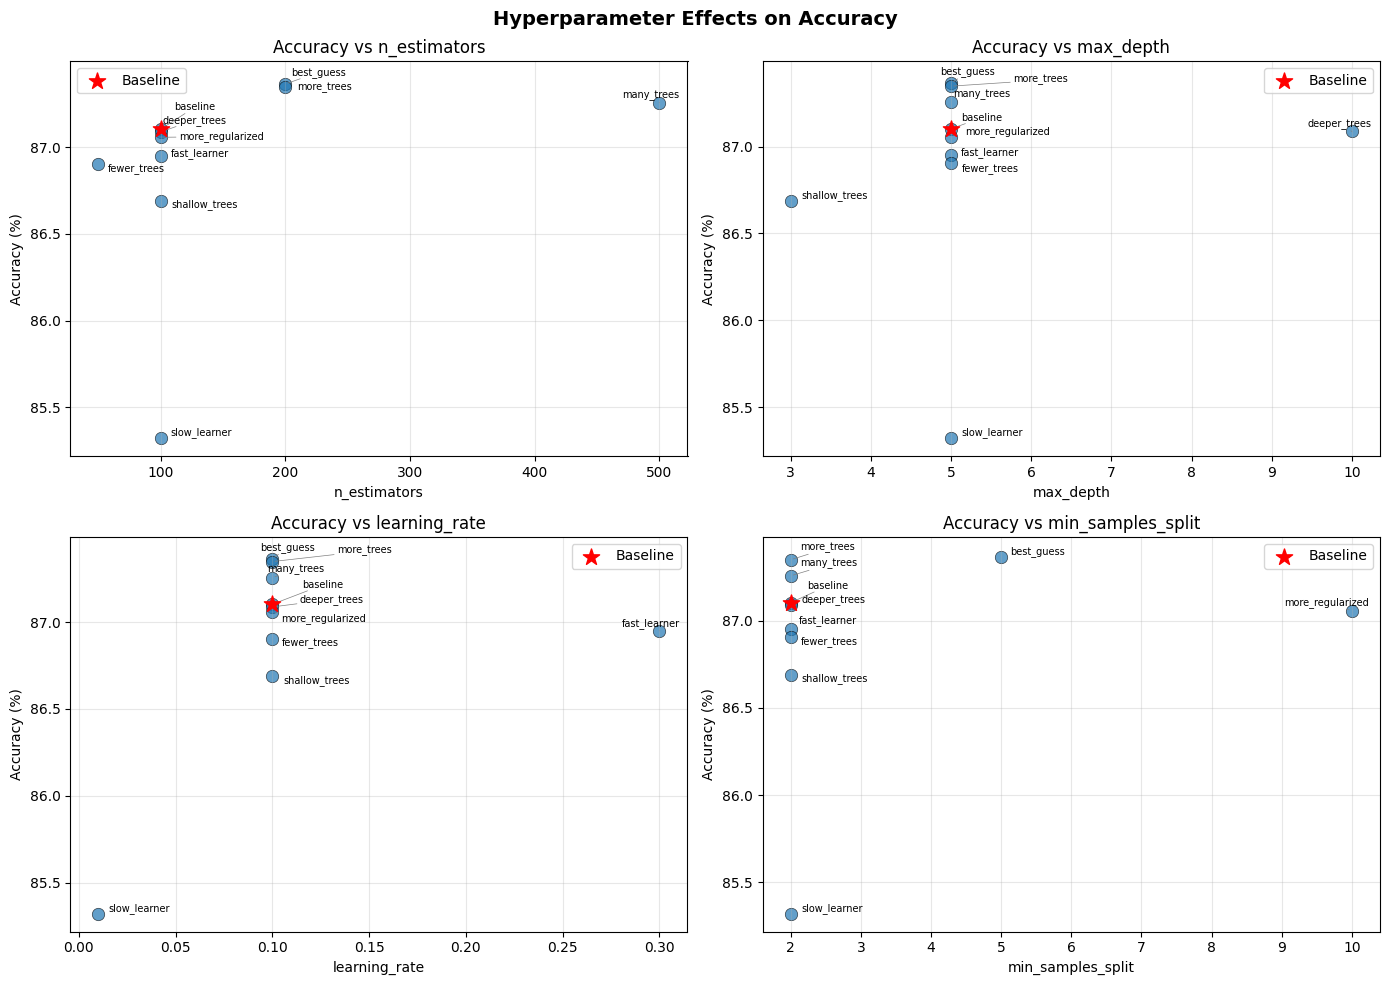

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Effects on Accuracy', fontsize=14, fontweight='bold')

params_to_plot = ['n_estimators', 'max_depth', 'learning_rate', 'min_samples_split']

for ax, param in zip(axes.flat, params_to_plot):
    ax.scatter(results_df[param], results_df['accuracy'] * 100,
               s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Build a list of text objects for adjust_text
    texts = []
    for _, row in results_df.iterrows():
        t = ax.text(
            row[param], row['accuracy'] * 100,
            row['experiment'],
            fontsize=7
        )
        texts.append(t)

    # Let adjustText automatically reposition labels to avoid overlaps
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
    )

    # Highlight baseline
    baseline_row = results_df[results_df['experiment'] == 'baseline']
    ax.scatter(baseline_row[param], baseline_row['accuracy'] * 100,
               s=150, color='red', marker='*', zorder=5, label='Baseline')

    ax.set_xlabel(param)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Accuracy vs {param}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

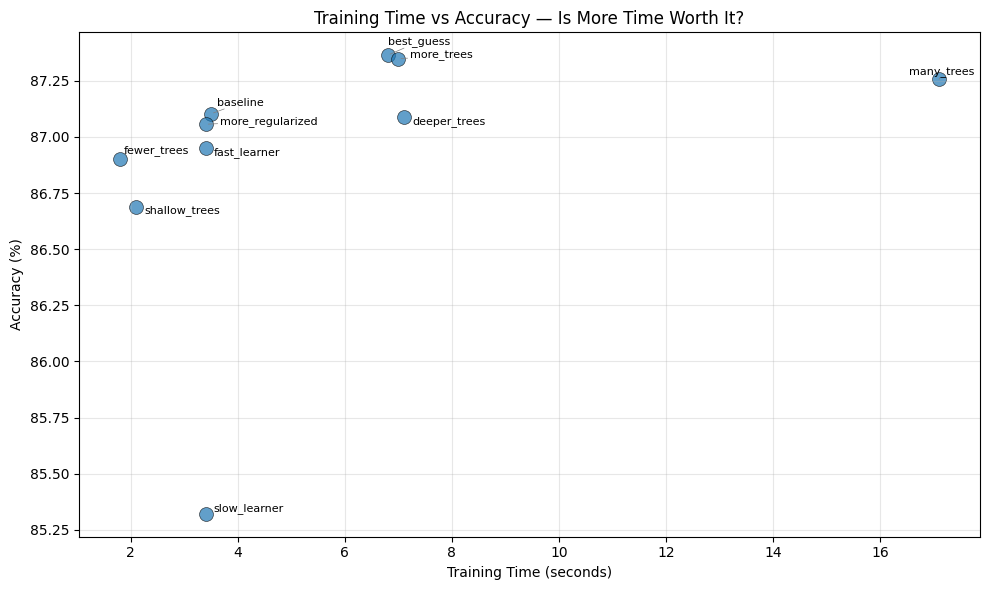

In [ ]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    results_df['train_time_sec'],
    results_df['accuracy'] * 100,
    s=100, alpha=0.7, edgecolors='black', linewidth=0.5
)

# Build text objects for adjust_text
texts = []
for _, row in results_df.iterrows():
    t = ax.text(
        row['train_time_sec'], row['accuracy'] * 100,
        row['experiment'],
        fontsize=8
    )
    texts.append(t)

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training Time vs Accuracy — Is More Time Worth It?')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-Validation Check

Our single train/test split might be lucky or unlucky. Let's verify the top results
with 5-fold cross-validation to make sure they're robust.

In [ ]:
# Cross-validate the top 3 experiments + baseline
top_experiments = results_df.head(3)['experiment'].tolist()
if 'baseline' not in top_experiments:
    top_experiments.append('baseline')

print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

cv_results = []
for name in top_experiments:
    params = experiments[name]
    model = GradientBoostingClassifier(**params, random_state=42)
    
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    
    cv_results.append({
        'experiment': name,
        'cv_mean': scores.mean(),
        'cv_std': scores.std(),
        'cv_min': scores.min(),
        'cv_max': scores.max()
    })
    
    print(f"{name:20s}  mean={scores.mean():.4f}  std={scores.std():.4f}  "
          f"range=[{scores.min():.4f}, {scores.max():.4f}]")

print("=" * 70)
print("\nNote: If the std is high, the result isn't stable.")
print("A small improvement with high variance isn't a real improvement.")

5-FOLD CROSS-VALIDATION
best_guess            mean=0.6495  std=0.1232  range=[0.4939, 0.7975]
more_trees            mean=0.6477  std=0.1259  range=[0.4820, 0.7975]
many_trees            mean=0.6104  std=0.1784  range=[0.3114, 0.8002]
baseline              mean=0.6794  std=0.0954  range=[0.5455, 0.7943]

Note: If the std is high, the result isn't stable.
A small improvement with high variance isn't a real improvement.


### Part 1 Summary

| Metric | Value |
|--------|-------|
| Baseline accuracy | 87.10% |
| Best manual accuracy | 87.36% |
| Improvement | +0.26 pp |
| Total experiments | 10 |
| Total time spent | ~1 min compute, but the real cost is *your* time choosing params |

**Observations:**
- **Biggest impact:** `learning_rate` — the slow_learner (0.01) dropped to 85.32%, a 1.78pp swing. By far the largest movement across all experiments.
- **Almost no effect:** `min_samples_split` — changing from 2 to 10 only moved accuracy by 0.04pp. Barely noise.
- **Was the improvement worth the effort?** For 10 experiments, +0.26pp is marginal. More importantly, manual tuning only found an incremental improvement (more trees) rather than a fundamentally different strategy. You'd never have tried `learning_rate=0.028` by hand.

**Pain points of manual tuning:**
- Only tested 10 combinations out of a massive search space (3 × 4 × 3 × 3 = 108 combinations just from the plan's suggested values)
- No systematic exploration — relied on intuition and one-at-a-time variation
- Each experiment required manually choosing parameters
- Hard to know if we found the optimal combination — and we didn't (Vertex AI found a better one)

This motivates Part 2: letting Vertex AI's Bayesian optimization explore the space systematically.

## Part 2: Vertex AI Hyperparameter Tuning

Now we'll let Vertex AI search the hyperparameter space systematically using Bayesian optimization.

### What Changes from Lab 2

Our Lab 2 `train.py` needs one key modification: it must **report the metric back to Vertex AI**
so the tuning service knows which trials performed well.

Vertex AI uses the `cloudml-hypertune` library for this. The training script calls
`hypertune.report_hyperparameter_tuning_metric()` after evaluation, and Vertex AI
uses that feedback to choose the next set of hyperparameters (Bayesian optimization).

### Step 1: Update the Training Script

We need to create a new version of `train.py` that reports metrics to Vertex AI.
Save this as `lab3_train.py` in your `ml_labs/` folder.

**Key differences from Lab 2's `train.py`:**
1. Added `cloudml-hypertune` for reporting metrics
2. Reports accuracy back to Vertex AI after evaluation
3. Everything else stays the same — same data loading, preprocessing, model training

In [ ]:
%%writefile lab3_train.py
"""
Lab 3: Custom training script with hyperparameter tuning support.

Based on Lab 2's train.py with one key addition:
- Reports metrics back to Vertex AI using cloudml-hypertune

Usage (local):
    python lab3_train.py --data-path census_income.csv --n-estimators 100 --max-depth 5

Usage (Vertex AI tuning):
    Vertex AI passes --n-estimators, --max-depth, etc. automatically per trial
"""

import argparse
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import joblib
import os


def load_data(data_path):
    """Load data from GCS or local path."""
    print(f"Loading data from: {data_path}")
    if data_path.endswith('.parquet'):
        df = pd.read_parquet(data_path)
    else:
        df = pd.read_csv(data_path)
    print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
    return df


def preprocess_data(df, target_column):
    """Prepare features and target."""
    X = df.drop(columns=[target_column])
    y = df[target_column].str.strip()
    y = (y == '>50K').astype(int)
    X = pd.get_dummies(X, drop_first=True)
    return X, y


def save_model(model, model_dir):
    """Save trained model."""
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, 'model.joblib')
    joblib.dump(model, model_path)
    print(f"Model saved to: {model_path}")


def main():
    parser = argparse.ArgumentParser()
    
    # Data arguments
    parser.add_argument('--data-path', type=str, required=True)
    parser.add_argument('--target-column', type=str, default='income_bracket')
    parser.add_argument('--model-dir', type=str, default='/tmp/model')
    
    # Hyperparameters — Vertex AI tuning will override these
    parser.add_argument('--n-estimators', type=int, default=100)
    parser.add_argument('--max-depth', type=int, default=5)
    parser.add_argument('--learning-rate', type=float, default=0.1)
    parser.add_argument('--min-samples-split', type=int, default=2)
    
    args = parser.parse_args()
    
    # Load and preprocess
    df = load_data(args.data_path)
    X, y = preprocess_data(df, args.target_column)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Train
    hyperparams = {
        'n_estimators': args.n_estimators,
        'max_depth': args.max_depth,
        'learning_rate': args.learning_rate,
        'min_samples_split': args.min_samples_split,
    }
    
    print(f"\nHyperparameters: {hyperparams}")
    
    model = GradientBoostingClassifier(**hyperparams, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nResults:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
    
    # ========================================================
    # KEY ADDITION FOR LAB 3: Report metric to Vertex AI
    # ========================================================
    # cloudml-hypertune is only available inside Vertex AI containers.
    # When running locally, this block is safely skipped.
    try:
        import hypertune
        hpt = hypertune.HyperTune()
        hpt.report_hyperparameter_tuning_metric(
            hyperparameter_metric_tag='accuracy',
            metric_value=accuracy
        )
        print(f"Reported accuracy={accuracy:.4f} to Vertex AI tuning service")
    except ImportError:
        print("(cloudml-hypertune not available — running locally, skipping metric report)")
    
    # Save model
    save_model(model, args.model_dir)


if __name__ == '__main__':
    main()

Writing lab3_train.py


### Step 2: Update the Dockerfile

We need to add `cloudml-hypertune` to our container. Save this as `Dockerfile` in `ml_labs/`.

**Only change from Lab 2:** added `cloudml-hypertune` to pip install and changed the entrypoint to `lab3_train.py`.

In [ ]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app

# Install dependencies
RUN pip install --no-cache-dir \
    pandas \
    scikit-learn \
    joblib \
    gcsfs \
    cloudml-hypertune

# Copy training script
COPY lab3_train.py .

ENTRYPOINT ["python", "lab3_train.py"]

Writing Dockerfile


### Step 3: Build and Push the Container

In [13]:
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = "carty-470812-ml-census-data"

IMAGE_URI = f"gcr.io/{PROJECT_ID}/census-hpt:v1"

print(f"Container image: {IMAGE_URI}")
print(f"\nBuilding and pushing...")
print(f"This will take a few minutes.")

Container image: gcr.io/carty-470812/census-hpt:v1

Building and pushing...
This will take a few minutes.


In [ ]:
# Build and push using Cloud Build
!gcloud builds submit \
    --tag {IMAGE_URI} \
    --project {PROJECT_ID} \
    --timeout=20m \
    .

Creating temporary archive of 15 file(s) totalling 4.0 MiB before compression.
Uploading tarball of [.] to [gs://carty-470812_cloudbuild/source/1771659618.820679-098b4b95f35743c2815fa90d0ae060e6.tgz]
Created [https://cloudbuild.googleapis.com/v1/projects/carty-470812/locations/global/builds/087355d4-9971-437a-8433-91a6aae652b8].
Logs are available at [ https://console.cloud.google.com/cloud-build/builds/087355d4-9971-437a-8433-91a6aae652b8?project=873708835509 ].
Waiting for build to complete. Polling interval: 1 second(s).
----------------------------- REMOTE BUILD OUTPUT ------------------------------
starting build "087355d4-9971-437a-8433-91a6aae652b8"

FETCHSOURCE
Fetching storage object: gs://carty-470812_cloudbuild/source/1771659618.820679-098b4b95f35743c2815fa90d0ae060e6.tgz#1771659621050176
Copying gs://carty-470812_cloudbuild/source/1771659618.820679-098b4b95f35743c2815fa90d0ae060e6.tgz#1771659621050176...
/ [1 files][484.6 KiB/484.6 KiB]                                      

### Step 4: Configure and Launch Hyperparameter Tuning Job

This is the main event. We define:
1. **Search space** — ranges for each hyperparameter
2. **Optimization goal** — maximize accuracy
3. **Budget** — max trials and parallel workers

Vertex AI uses **Bayesian optimization**: it learns from completed trials to intelligently
choose the next set of hyperparameters. Much smarter than random or grid search.

In [ ]:
from google.cloud import aiplatform
from google.cloud.aiplatform import hyperparameter_tuning as hpt
from datetime import datetime

# Initialize Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=f"gs://{BUCKET_NAME}"
)

timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
GCS_DATA_PATH = f"gs://{BUCKET_NAME}/data/census_income.csv"

print(f"Timestamp: {timestamp}")
print(f"Data path: {GCS_DATA_PATH}")
print(f"Image: {IMAGE_URI}")

Timestamp: 20260221-085147
Data path: gs://carty-470812-ml-census-data/data/census_income.csv
Image: gcr.io/carty-470812/census-hpt:v1


In [ ]:
# Define the custom training job (base job that tuning will run multiple times)
custom_job = aiplatform.CustomJob(
    display_name=f"census-hpt-trial-{timestamp}",
    worker_pool_specs=[
        {
            "machine_spec": {
                "machine_type": "n1-standard-4",  # ~$0.19/hour
            },
            "replica_count": 1,
            "container_spec": {
                "image_uri": IMAGE_URI,
                "args": [
                    f"--data-path={GCS_DATA_PATH}",
                    "--target-column=income_bracket",
                ],
            },
        }
    ],
)

print("Custom job template created")

Custom job template created


In [ ]:
# Define and launch the hyperparameter tuning job
hpt_job = aiplatform.HyperparameterTuningJob(
    display_name=f"census-hpt-{timestamp}",
    custom_job=custom_job,
    
    # What to optimize
    metric_spec={'accuracy': 'maximize'},
    
    # Search space — Vertex AI will explore within these ranges
    parameter_spec={
        'n-estimators': hpt.IntegerParameterSpec(
            min=50, max=500, scale='linear'
        ),
        'max-depth': hpt.IntegerParameterSpec(
            min=3, max=15, scale='linear'
        ),
        'learning-rate': hpt.DoubleParameterSpec(
            min=0.01, max=0.3, scale='log'  # log scale: explores small values more
        ),
        'min-samples-split': hpt.IntegerParameterSpec(
            min=2, max=20, scale='linear'
        ),
    },
    
    # Budget
    max_trial_count=20,       # Total trials to run
    parallel_trial_count=2,   # Run 2 at a time (cost vs speed tradeoff)
    
    # Search algorithm — Bayesian is default and best for most cases
    search_algorithm=None,    # None = Bayesian optimization (recommended)
)

print("Hyperparameter tuning job configured!")
print(f"  Trials: 20 (2 parallel)")
print(f"  Estimated cost: ~$5-15")
print(f"  Estimated time: ~30-60 minutes")
print(f"\nNote: learning-rate uses LOG scale because small differences")
print(f"  at low values (0.01 vs 0.05) matter more than at high values (0.2 vs 0.25)")

Hyperparameter tuning job configured!
  Trials: 20 (2 parallel)
  Estimated cost: ~$5-15
  Estimated time: ~30-60 minutes

Note: learning-rate uses LOG scale because small differences
  at low values (0.01 vs 0.05) matter more than at high values (0.2 vs 0.25)


In [ ]:
# Launch the tuning job!
print("Launching hyperparameter tuning job...")
print(f"Monitor in console: https://console.cloud.google.com/vertex-ai/training/hyperparameter-tuning-jobs?project={PROJECT_ID}")
print("\nThis will take ~30-60 minutes. You can check progress in the console.")

hpt_job.run()

print("\nTuning job complete!")

Launching hyperparameter tuning job...
Monitor in console: https://console.cloud.google.com/vertex-ai/training/hyperparameter-tuning-jobs?project=carty-470812

This will take ~30-60 minutes. You can check progress in the console.
Creating HyperparameterTuningJob
HyperparameterTuningJob created. Resource name: projects/873708835509/locations/us-central1/hyperparameterTuningJobs/7540720037737267200
To use this HyperparameterTuningJob in another session:
hpt_job = aiplatform.HyperparameterTuningJob.get('projects/873708835509/locations/us-central1/hyperparameterTuningJobs/7540720037737267200')
View HyperparameterTuningJob:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/7540720037737267200?project=873708835509
HyperparameterTuningJob projects/873708835509/locations/us-central1/hyperparameterTuningJobs/7540720037737267200 current state:
2
HyperparameterTuningJob projects/873708835509/locations/us-central1/hyperparameterTuningJobs/7540720037737267200 current state

### Step 5: Retrieve and Analyze Results

In [ ]:
# Get all trial results
trials = hpt_job.trials

# Parse into a DataFrame
trial_data = []
for trial in trials:
    row = {
        'trial_id': trial.id,
        'accuracy': trial.final_measurement.metrics[0].value,
        'state': trial.state.name,
    }
    for param in trial.parameters:
        row[param.parameter_id] = param.value
    trial_data.append(row)

trials_df = pd.DataFrame(trial_data)
trials_df = trials_df.sort_values('accuracy', ascending=False).reset_index(drop=True)

print(f"VERTEX AI HYPERPARAMETER TUNING RESULTS")
print(f"{'='*80}")
print(f"Completed trials: {len(trials_df)}")
print(f"\nTop 5 trials:")
trials_df.head()

VERTEX AI HYPERPARAMETER TUNING RESULTS
Completed trials: 20

Top 5 trials:


,trial_id,accuracy,state,learning-rate,max-depth,min-samples-split,n-estimators
0,13,0.875940,SUCCEEDED,0.027738,8.0,7.0,385.0
1,17,0.875633,SUCCEEDED,0.026937,9.0,20.0,350.0
2,2,0.875633,SUCCEEDED,0.026653,8.0,8.0,369.0
3,12,0.875173,SUCCEEDED,0.028544,9.0,18.0,375.0
4,7,0.875019,SUCCEEDED,0.027084,9.0,8.0,361.0


In [ ]:
# Compare: Manual best vs Vertex AI best vs Baseline
vertex_best = trials_df.iloc[0]

print("FINAL COMPARISON")
print("=" * 70)
print(f"{'Method':<30} {'Accuracy':>10} {'Improvement':>15}")
print("-" * 70)
print(f"{'Lab 2 Baseline':<30} {baseline_acc*100:>9.2f}% {'—':>15}")
print(f"{'Manual Best (' + best_row['experiment'] + ')':<30} {best_row['accuracy']*100:>9.2f}% "
      f"{(best_row['accuracy'] - baseline_acc)*100:>+14.2f}pp")
print(f"{'Vertex AI Best (trial ' + str(vertex_best['trial_id']) + ')':<30} "
      f"{vertex_best['accuracy']*100:>9.2f}% "
      f"{(vertex_best['accuracy'] - baseline_acc)*100:>+14.2f}pp")
print("=" * 70)

print(f"\nVertex AI best hyperparameters:")
for col in ['n-estimators', 'max-depth', 'learning-rate', 'min-samples-split']:
    if col in vertex_best:
        print(f"  {col}: {vertex_best[col]}")

FINAL COMPARISON
Method                           Accuracy     Improvement
----------------------------------------------------------------------
Lab 2 Baseline                     87.10%               —
Manual Best (best_guess)           87.36%          +0.26pp
Vertex AI Best (trial 13)          87.59%          +0.49pp

Vertex AI best hyperparameters:
  n-estimators: 385.0
  max-depth: 8.0
  learning-rate: 0.02773800143431077
  min-samples-split: 7.0


### Part 2 Summary

| Metric | Manual Tuning | Vertex AI Tuning |
|--------|--------------|------------------|
| Trials run | 10 | 20 |
| Time spent | ~1 min compute + decision time | ~60 min (fully automated) |
| Cost | $0 (local) | ~$3-5 |
| Best accuracy | 87.36% | 87.59% |

**Key observation:** Vertex AI found a fundamentally different strategy than manual tuning. Manual best used the standard `learning_rate=0.1` with 200 trees. Vertex AI discovered that a **much lower learning rate (~0.028) with many more trees (~385)** works better. This is a well-known gradient boosting pattern — slower learning + more iterations = better generalization — but it's not something you'd easily stumble on manually.

The top 5 Vertex AI trials all clustered around `learning_rate ≈ 0.027, n_estimators ≈ 350-385, max_depth ≈ 8-9`. That consistency demonstrates Bayesian optimization genuinely learning the landscape, not randomly searching.


## Part 3: Visualization & Analysis

Now let's combine all results (manual + Vertex AI) and create the full visualization suite.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# Combine manual + Vertex AI results for analysis
# Use whichever dataset has more data (likely trials_df from Vertex AI)
# For now, visualize Vertex AI trials since they cover the space more systematically

# If Vertex AI hasn't run yet, use manual results
try:
    plot_df = trials_df.copy()
    plot_source = "Vertex AI"
    param_cols = ['n-estimators', 'max-depth', 'learning-rate', 'min-samples-split']
except NameError:
    plot_df = results_df.copy()
    plot_source = "Manual"
    param_cols = ['n_estimators', 'max_depth', 'learning_rate', 'min_samples_split']

print(f"Visualizing {len(plot_df)} trials from {plot_source} tuning")

Visualizing 20 trials from Vertex AI tuning


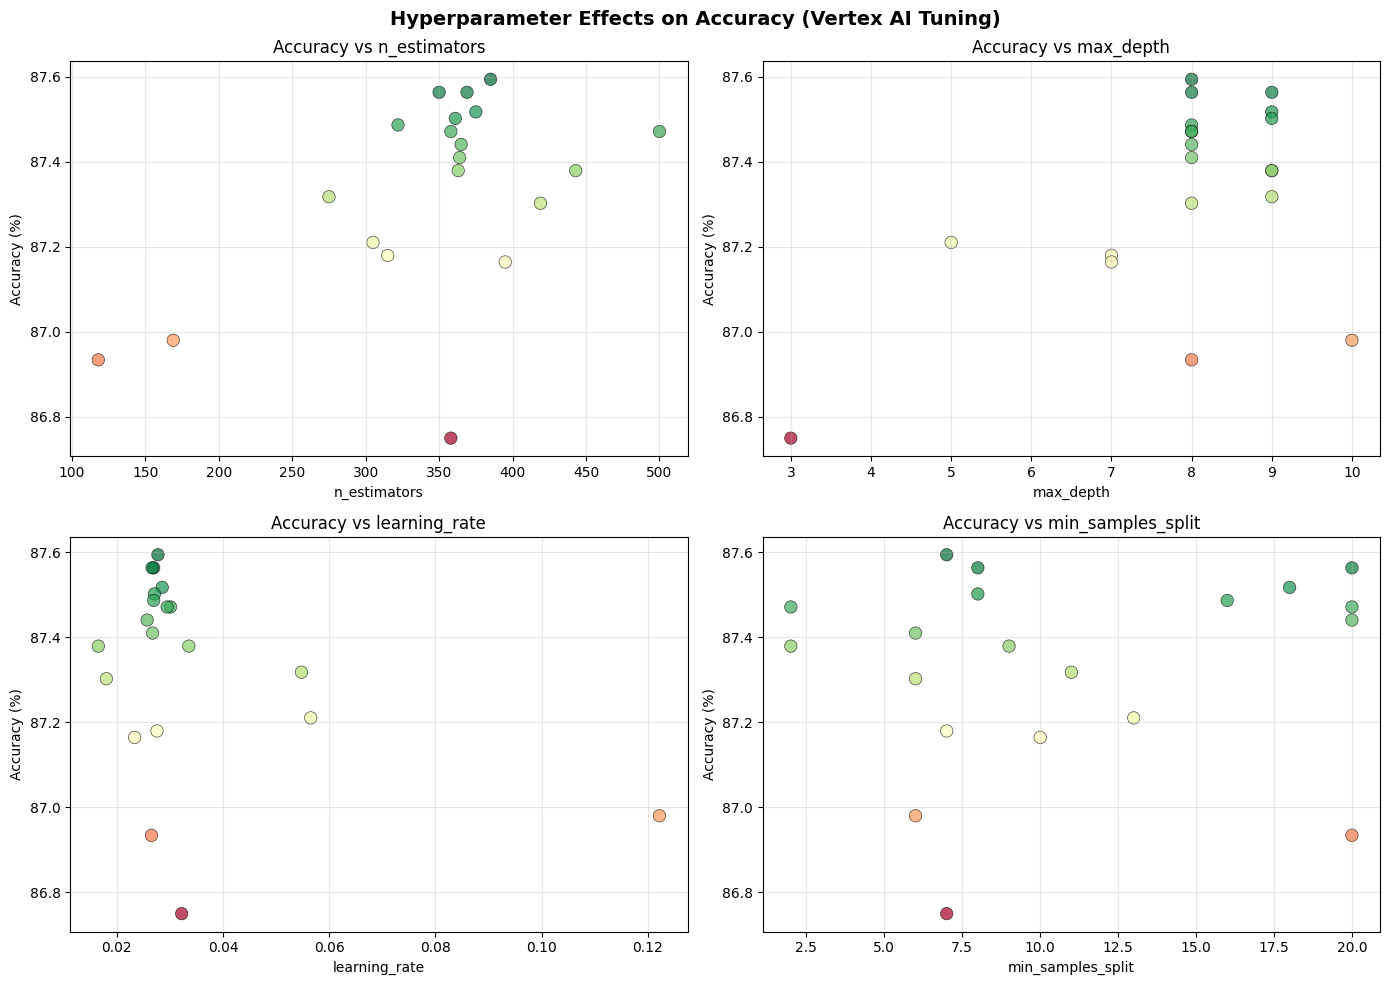

In [ ]:
# 1. Hyperparameter vs Accuracy scatter plots (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Hyperparameter Effects on Accuracy ({plot_source} Tuning)', 
             fontsize=14, fontweight='bold')

param_labels = ['n_estimators', 'max_depth', 'learning_rate', 'min_samples_split']

for ax, col, label in zip(axes.flat, param_cols, param_labels):
    sc = ax.scatter(
        plot_df[col], 
        plot_df['accuracy'] * 100,
        c=plot_df['accuracy'] * 100,
        cmap='RdYlGn',
        s=80, alpha=0.7, edgecolors='black', linewidth=0.5
    )
    ax.set_xlabel(label)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Accuracy vs {label}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

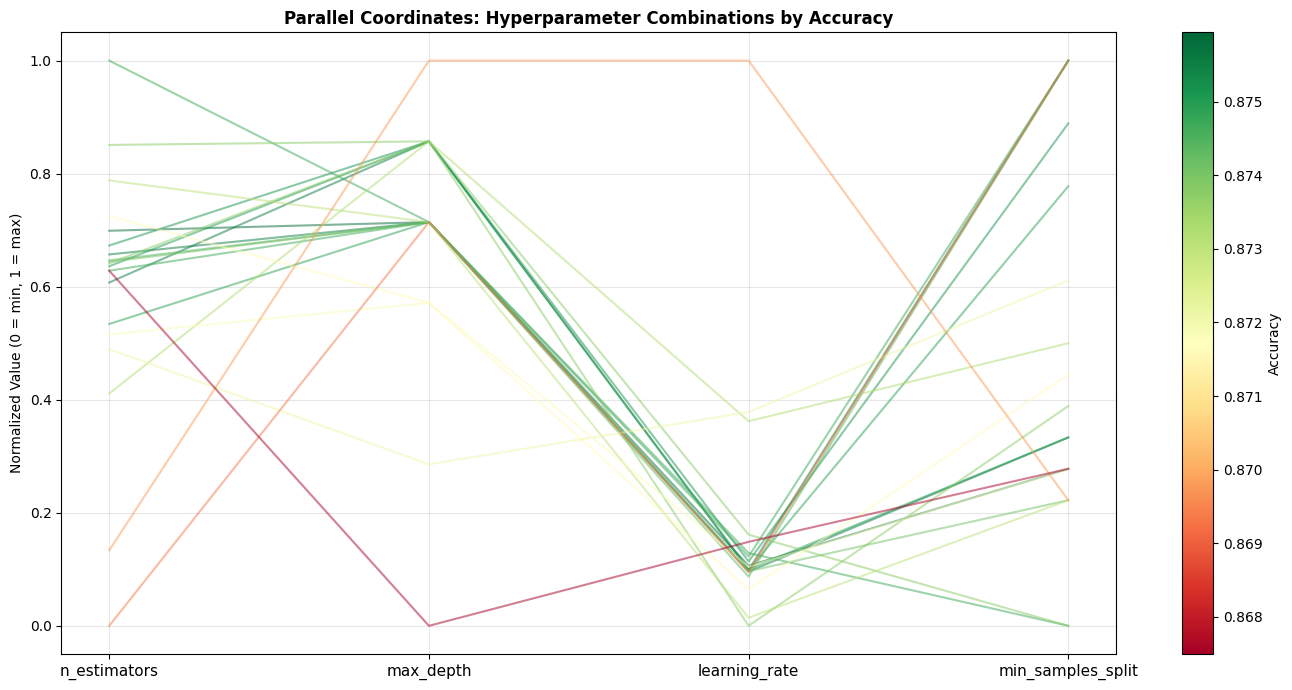

In [ ]:
# 2. Parallel Coordinates Plot
# Shows each trial as a line connecting its hyperparameter values
# Good trials (high accuracy) should cluster in certain regions

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(14, 7))

# Normalize each parameter to [0, 1] for comparable axes
norm_df = plot_df.copy()
for col in param_cols:
    col_min = norm_df[col].min()
    col_max = norm_df[col].max()
    if col_max > col_min:
        norm_df[col] = (norm_df[col] - col_min) / (col_max - col_min)
    else:
        norm_df[col] = 0.5

# Color by accuracy
cmap = plt.cm.RdYlGn
norm = Normalize(vmin=plot_df['accuracy'].min(), vmax=plot_df['accuracy'].max())

x_positions = range(len(param_cols))

for _, row in norm_df.iterrows():
    color = cmap(norm(row['accuracy']))
    values = [row[col] for col in param_cols]
    ax.plot(x_positions, values, color=color, alpha=0.5, linewidth=1.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(param_labels, fontsize=11)
ax.set_ylabel('Normalized Value (0 = min, 1 = max)')
ax.set_title('Parallel Coordinates: Hyperparameter Combinations by Accuracy', fontweight='bold')

# Add colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Accuracy')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

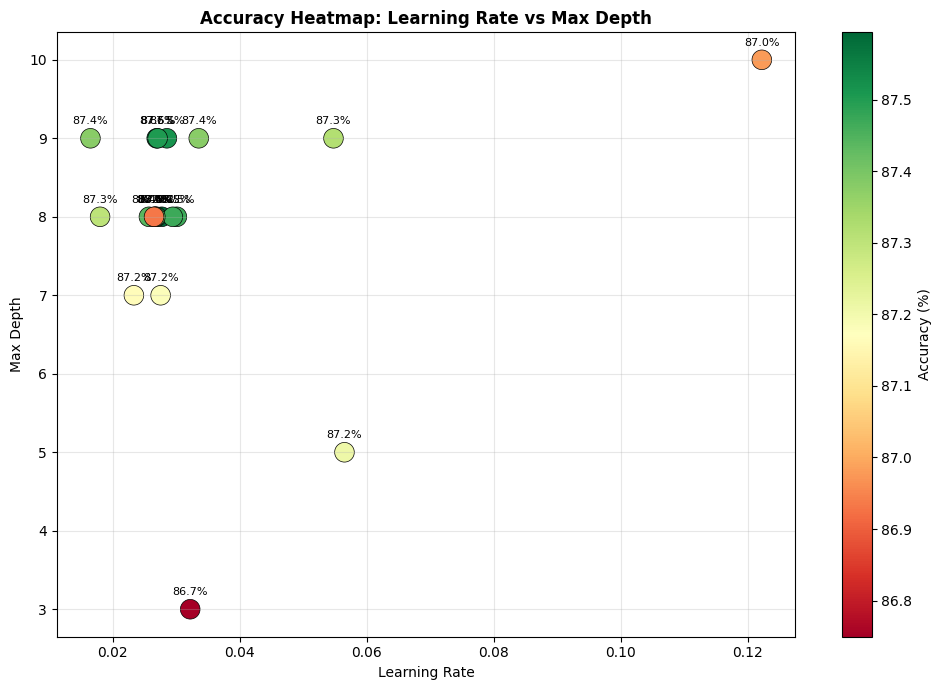

In [ ]:
# 3. Heatmap: learning_rate vs max_depth (the two most impactful params typically)
fig, ax = plt.subplots(figsize=(10, 7))

lr_col = param_cols[2]   # learning-rate or learning_rate
md_col = param_cols[1]   # max-depth or max_depth

scatter = ax.scatter(
    plot_df[lr_col],
    plot_df[md_col],
    c=plot_df['accuracy'] * 100,
    cmap='RdYlGn',
    s=200,
    edgecolors='black',
    linewidth=0.5
)

# Label each point with accuracy
for _, row in plot_df.iterrows():
    ax.annotate(f"{row['accuracy']*100:.1f}%",
                (row[lr_col], row[md_col]),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8)

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Max Depth')
ax.set_title('Accuracy Heatmap: Learning Rate vs Max Depth', fontweight='bold')
plt.colorbar(scatter, label='Accuracy (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

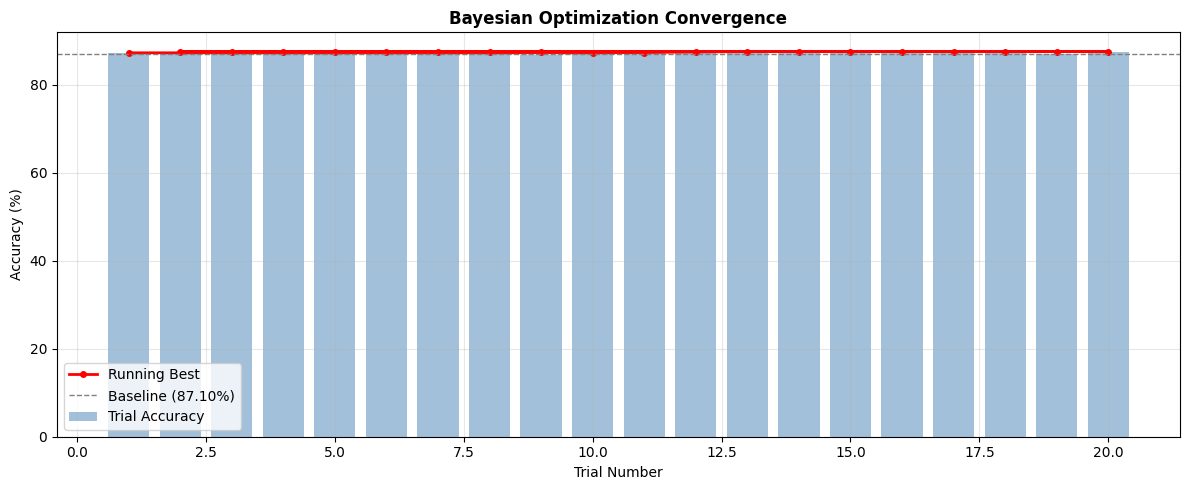


The best trial was found at trial #13
Bayesian optimization needed more exploration


In [ ]:
# 4. Convergence Plot (Vertex AI only) — shows how Bayesian optimization improves over trials
try:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Trial IDs in order they were run
    ordered = trials_df.sort_values('trial_id')
    trial_ids = ordered['trial_id'].astype(int)
    accuracies = ordered['accuracy'] * 100
    
    # Running best
    running_best = accuracies.expanding().max()
    
    ax.bar(trial_ids, accuracies, alpha=0.5, color='steelblue', label='Trial Accuracy')
    ax.plot(trial_ids, running_best, color='red', linewidth=2, marker='o', 
            markersize=4, label='Running Best')
    
    # Baseline reference
    ax.axhline(y=baseline_acc * 100, color='gray', linestyle='--', 
               linewidth=1, label=f'Baseline ({baseline_acc*100:.2f}%)')
    
    ax.set_xlabel('Trial Number')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Bayesian Optimization Convergence', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nThe best trial was found at trial #{ordered.loc[ordered['accuracy'].idxmax(), 'trial_id']}")
    print(f"Bayesian optimization {'found a good result early' if int(ordered.loc[ordered['accuracy'].idxmax(), 'trial_id']) < 10 else 'needed more exploration'}")
    
except NameError:
    print("Vertex AI trials not available yet. Run Part 2 first.")

### Final Analysis & Key Learnings

In [ ]:
# Correlation between each hyperparameter and accuracy
print("HYPERPARAMETER IMPACT ANALYSIS")
print("=" * 50)
print("\nCorrelation with accuracy (higher magnitude = more impact):")

for col, label in zip(param_cols, param_labels):
    corr = plot_df[col].corr(plot_df['accuracy'])
    bar = '█' * int(abs(corr) * 20)
    direction = '+' if corr > 0 else '-'
    print(f"  {label:25s} {corr:+.3f}  {direction} {bar}")

print("\n(Positive = higher values help, Negative = higher values hurt)")
print("(This is a rough guide — interactions between params also matter)")

HYPERPARAMETER IMPACT ANALYSIS

Correlation with accuracy (higher magnitude = more impact):
  n_estimators              +0.535  + ██████████
  max_depth                 +0.522  + ██████████
  learning_rate             -0.385  - ███████
  min_samples_split         +0.118  + ██

(Positive = higher values help, Negative = higher values hurt)
(This is a rough guide — interactions between params also matter)


### Lab 3 Summary

#### Results

| Metric | Baseline | Manual Best | Vertex AI Best |
|--------|----------|-------------|----------------|
| Accuracy | 87.10% | 87.36% | 87.59% |
| ROC AUC | 0.9304 | 0.9321 | ~0.932+ |
| Training cost | $0.04 (Lab 2) | $0 (local) | ~$3-5 |

#### Key Learnings

1. **Most impactful hyperparameters:** `n_estimators` (+0.535 correlation) and `max_depth` (+0.522) had the strongest positive correlation with accuracy. But `learning_rate` had the biggest *negative* impact when wrong — the 0.01 experiment cratered by 1.78pp.

2. **Least impactful hyperparameter:** `min_samples_split` (+0.118 correlation). Barely moved the needle across all 20 Vertex AI trials.

3. **Diminishing returns observed at:** ~87.5%. The top 5 Vertex AI trials clustered between 87.50–87.59%, suggesting we're near the ceiling for this algorithm + dataset + feature set. Going further would likely require better features or a different algorithm (XGBoost, neural nets), not more tuning.

4. **Was automated tuning worth the cost?** Context-dependent. For ~$5 it found +0.49pp and a fundamentally better strategy (low learning rate + many trees) that manual tuning missed entirely. In production at scale, 0.49pp could matter. For a learning exercise, the bigger value was seeing *how* Bayesian optimization converged — the top trials clustering in the same region of parameter space demonstrates the algorithm is genuinely learning.

#### Certification Exam Takeaways

- **Bayesian optimization** learns from past trials → more efficient than grid/random search
- **`learning_rate` uses log scale** because small values (0.01 vs 0.05) matter more than large values (0.2 vs 0.25)
- **`parallel_trial_count`** trades quality for speed — more parallel trials = faster but Bayesian has less feedback per decision
- **`cloudml-hypertune`** is how training scripts report metrics back to Vertex AI's tuning service
- **Hyperparameter tuning has diminishing returns** — going from 80% to 85% is huge; 87% to 87.5% may not justify the cost
- **Cross-validation** is essential to verify improvements are real, not noise from a single train/test split
- **Low learning rate + more trees** is a classic gradient boosting best practice that Vertex AI rediscovered automatically

#### Journey So Far

| Lab | Best Accuracy | Key Technique | Cost |
|-----|--------------|---------------|------|
| Lab 1 | 86.23% | Algorithm selection (boosted trees) | ~$2 |
| Lab 2 | 87.10% | Custom training on Vertex AI | ~$0.04 |
| Lab 3 | 87.59% | Bayesian hyperparameter tuning | ~$3-5 |

Cumulative improvement from Lab 1 baseline (84.48%): **+3.11 percentage points**

In [14]:
# List resources to clean up
print("RESOURCES TO CLEAN UP")
print("=" * 50)
print("\nRun these commands to avoid ongoing charges:")
print(f"")
print(f"# Delete the HPT container image")
print(f"gcloud container images delete {IMAGE_URI} --quiet")
print(f"")
print(f"# Check for any running jobs")
print(f"gcloud ai hp-tuning-jobs list --region={REGION} --project={PROJECT_ID}")
print(f"")
print(f"# Cancel if any are still running")
print(f"# gcloud ai hp-tuning-jobs cancel <JOB_ID> --region={REGION} --project={PROJECT_ID}")

RESOURCES TO CLEAN UP

Run these commands to avoid ongoing charges:

# Delete the HPT container image
gcloud container images delete gcr.io/carty-470812/census-hpt:v1 --quiet

# Check for any running jobs
gcloud ai hp-tuning-jobs list --region=us-central1 --project=carty-470812

# Cancel if any are still running
# gcloud ai hp-tuning-jobs cancel <JOB_ID> --region=us-central1 --project=carty-470812
